In [5]:
import numpy as np 
import sympy as sp 
import matplotlib.pyplot as plt
from scipy import integrate

# %matplotlib widget

## Spring Mass Dampner System : 
* The position of the block $x(t)$ is the system output while the Force that we give to the system $F(t)$ is the system input 

* System Equation
$$ m\cdot x'' + c\cdot x' + k\cdot x = F(t) $$

* Frequency Response Function
$$ X(\omega) = \frac{F(\omega)}{(k - m\omega^2)+i\omega c} $$

* The impulse response of the system is [ Time domain response, solution to the ODE ] : 
$$ h(t) = \frac{e^{-\tau \omega_n t} \cdot sin(\omega_d t)}{m\omega_d} $$
$$ \tau = \frac{c}{2 \sqrt{km}} $$
$$ \omega_n = \sqrt(\frac{k}{m}) $$
$$ \omega_d = (\sqrt{1 - \tau^2})\cdot \omega_n $$

In [6]:
# SYSTEM PARAMETERS : 

m = 1
c = 0.2
k = 1

## <u>Plotting the Impulse Response Function :

In [7]:
def impulse_response(t) :
    tau = c/(2*np.sqrt(k*m)**0.5)
    wn  = np.sqrt(k/m)
    wd = np.sqrt(1-tau**2)*wn

    return np.exp(-tau*wn*t)*np.sin(wd*t)/(m*wd)
    

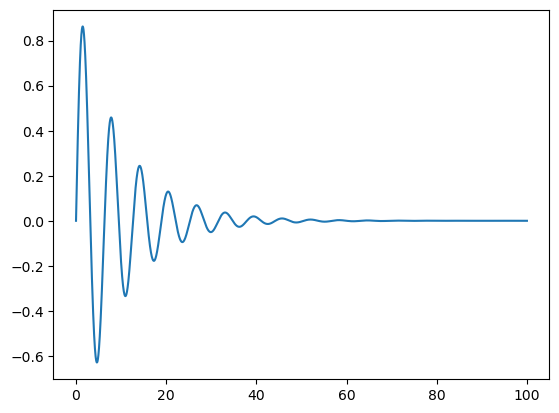

In [8]:
tvec = np.arange(0,100,0.005)

# Plotting
# impulse response function is only valid from t = 0 because the impulse is give at t = 0
# hence anything this function gives as output before t = 0 is invalid 

plt.close()
plt.plot(tvec, impulse_response(tvec))
plt.show()

## Fourier Transform :

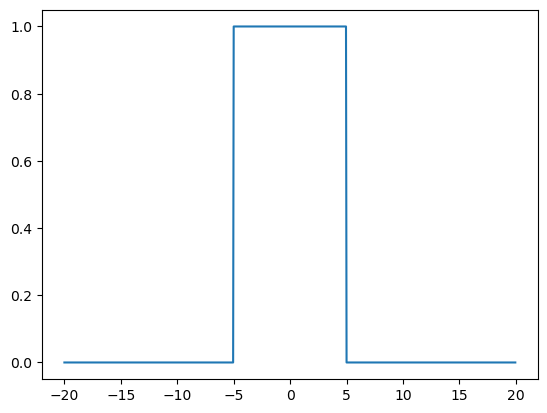

In [9]:
t = sp.Symbol('t')
tvec2 = np.arange(-20,20,0.05)
T0 = 5
xap = sp.Piecewise((1,(t> -T0) & (t< T0)), (0, True))
xap_num = sp.lambdify(t, xap)
plt.close()
plt.plot(tvec2, xap_num(tvec2))

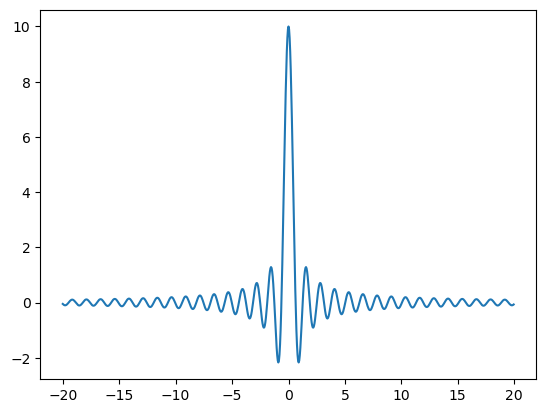

In [10]:
w = sp.symbols('omega')
cexp = sp.exp(-1.0j*w*t)

Xw = sp.integrate(xap*cexp, (t, -sp.oo, sp.oo))
Xw_num = sp.lambdify(w, Xw)

wvec = np.arange(-20,20,0.05)
plt.close()
plt.plot(wvec, Xw_num(wvec).real)

In [11]:
Xw.subs({w:5})

-0.2*I*exp(25.0*I) + 0.2*I*exp(-25.0*I)

---
## First Part 

* Verify the impulse response formula given in the class for spring-mass-damper system. You can do this by taking pulses of different shapes (square, triangular, etc.). Prove that irrespective of the shape of the pulse, the response tends to the impulse response function as the width of the pulse approaches zero.  

In [12]:
d = 0.001

def square(t, delta):
    return 1/delta if t < delta else 0

def triangular(t, delta) :
    return (2/delta)*(1-t/delta) if t < delta else 0

def sdof_fun(y, t, delta):
    '''Returns the derivative of the state vector y at a time t'''
    y0dot = y[1]
    y1dot = (triangular(t, delta)-c*y[1]-k*y[0])/m 
    return np.array([y0dot, y1dot])

tvec = np.arange(0,100,0.005)
sol = integrate.odeint(sdof_fun, np.array([0, 0]), tvec, args =  (d,))

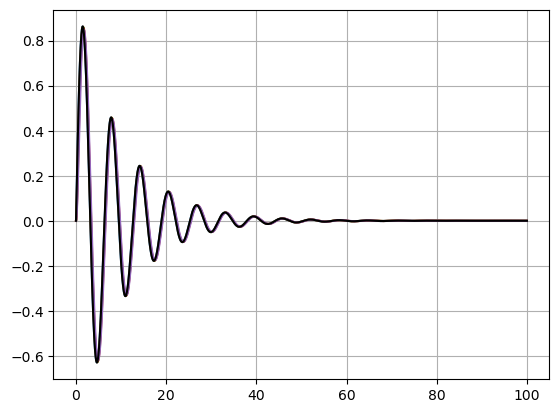

In [13]:
# disp = sol[:, 0]
# vel = sol[:, 1]
# plt.plot(tvec, disp)
plt.close()

delta = np.arange(0.001,1, 0.2)
for i in delta :
    sol = integrate.odeint(sdof_fun, np.array([0,0]), tvec, args = (i,))
    plt.plot(tvec, sol[:,0])

plt.plot(tvec, impulse_response(tvec), color = 'black')
plt.grid()
plt.show()

---
## Second Part 
* Verify that the Fourier transform (computed through quadrature) of the impulse response is indeed the Frequency response function 

In [14]:
integrate.simps(sol[0:50,0], tvec[0:50], dx = 0.005)

0.005565143465790414

In [15]:
frf_num = []
wvec    = np.arange(-100,100,0.05)
for w in wvec :
    frf_num.append(integrate.simps(sol[:,0]*np.exp(-1.0j*w*tvec), tvec, dx = 0.005))

In [16]:
np.exp(-1.0j*3*tvec)*sol[:,0]

array([0.00000000e+00+0.00000000e+00j, 3.11215022e-05-4.66857548e-07j,
       1.24173098e-04-3.72631089e-06j, ...,
       2.98415193e-06-4.44074878e-05j, 2.31353819e-06-4.43668875e-05j,
       1.64477668e-06-4.43151527e-05j])

In [17]:
def calculate_frf(w) : 
    return 1/(k - m*w**2 + 1.0j*c*w)

/home/erased/anaconda3/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


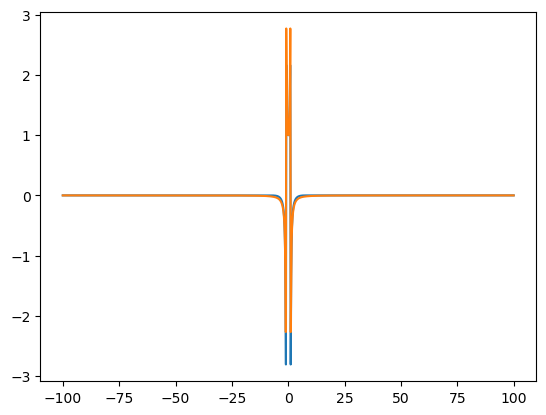

In [18]:
plt.plot(wvec, frf_num)
plt.plot(wvec, calculate_frf(wvec))

---
## Third Part 

* Verify that the inverse Fourier transform (computed through quadrature) of the Frequency response function is indeed the impulse response function

In [19]:
irf_num = []

for t in tvec : 
    irf_num.append(integrate.simps(frf_num*np.exp(1.0j*t*wvec)/(2*np.pi), wvec))

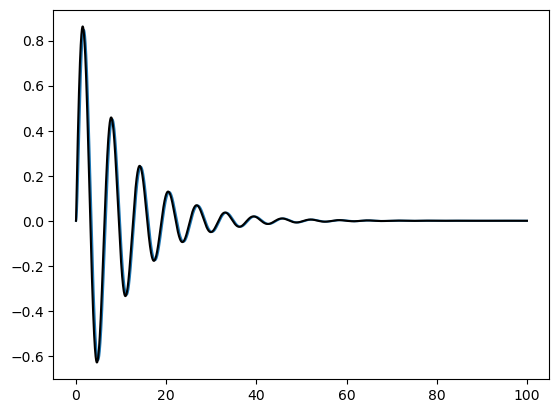

In [20]:
plt.plot(tvec, irf_num)
plt.plot(tvec, impulse_response(tvec), color = 'black')

---
## Part Four 
* Perform the ode integration of the equations of motion of sinusoidal forces with different excitation frequencies. Find the amplitude of the response at steady state for the different frequencies. Plot a curve of amplitude of response vs excitation frequency. This should effectively be the Frequency response function - this is how we determine the FRF experimentally (by actual measurements rather than simulation). Compare the generate plot with the formula given for the frequency response.  

In [62]:
def force(t, w):
    return np.cos(w*t)

def sdof_fun(y, t, w):
    '''Returns the derivative of the state vector y at a time t'''
    y0dot = y[1]
    y1dot = (force(t, w)-c*y[1]-k*y[0])/m 
    return np.array([y0dot, y1dot])

tvec = np.arange(0,200,0.05)
wvec1 = np.arange(-100,100,1)
# sol = integrate.odeint(sdof_fun, np.array([0, 0]), tvec)

In [63]:
frf_exp = []

for w in wvec1 : 
    sol = integrate.odeint(sdof_fun, np.array([0,0]), tvec, args=(w,))
    frf_exp.append(sol[1000:,0].max())

# plt.plot(tvec, sol[:,1])

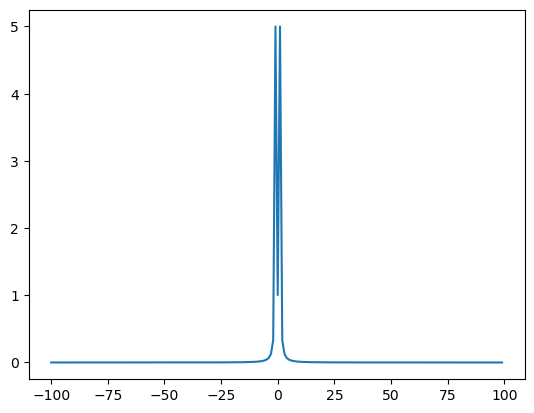

In [64]:
plt.plot(wvec1, frf_exp)


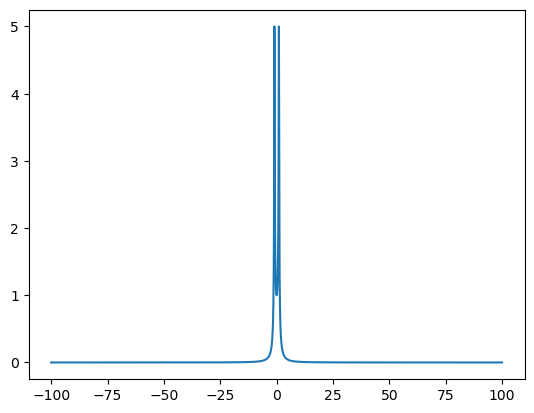

In [59]:
plt.plot(wvec, np.abs(calculate_frf(wvec)))

Hence the FRF calculated from the formula and the FRF obtained from the steady state amplitude of sin(wt) 


---
## Part Five 
*  In the class demonstration, we have seen that the solution obtained through the Frequency response function does not exactly match the solution obtained through the convolution integral/ODE integration. The FRF method fails to capture the transient. What can be changed in the computational procedure to ensure that solution obtained using both these methods exactly match? 

In [106]:
def force(t):
    return np.cos(t)

def sdof_fun(y, t):
    '''Returns the derivative of the state vector y at a time t'''
    y0dot = y[1]
    y1dot = (force(t)-c*y[1]-k*y[0])/m 
    return np.array([y0dot, y1dot])

tvec = np.arange(0,50,0.1)
# wvec1 = np.arange(-100,100,1)
sol = integrate.odeint(sdof_fun, np.array([0, 0]), tvec)

$$ X(\omega) = H(\omega)\cdot \left( \delta(\omega-\omega_0) + \delta(\omega + \omega_0) \right) / 2 $$
Now upon performing inverse Fourier Transform of $X(\omega)$
$$ \int_{-\infty}^{\infty} X(\omega)\cdot e^{i\omega t} \, d\omega  =  \frac{H(\omega_0)\cdot e^{i\omega_0 t} + H(-\omega_0)\cdot e^{-i\omega_0 t}}{2}$$
* In our Problem we take $\omega_0$ as 1 

/home/erased/anaconda3/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


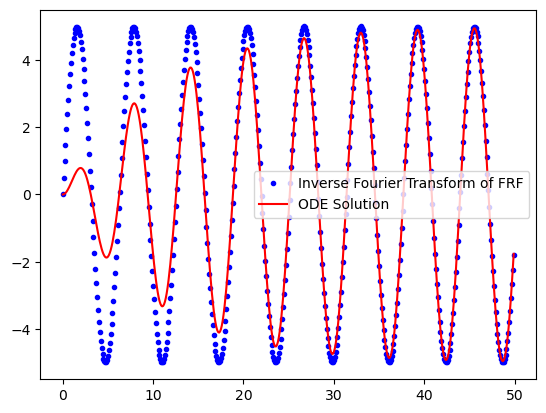

In [114]:
ift_results = (calculate_frf(1)*np.exp(1.0j*tvec) + calculate_frf(-1)*np.exp(-1.0j*tvec))/2
plt.plot(tvec, ift_results, '.', color='blue')
plt.plot(tvec, sol[:,0], color = 'red')
plt.legend(['Inverse Fourier Transform of FRF', 'ODE Solution'])

In [108]:
def calculate_ilpt(t) : 
    return 5*np.sin(t) - 5.02518*np.exp(-0.1*t)*np.sin(0.99498*t)

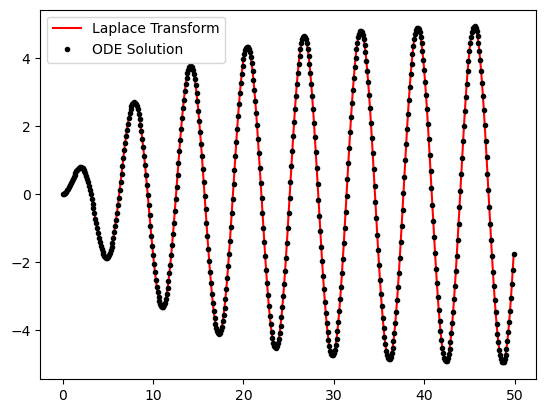

In [113]:
plt.plot(tvec, calculate_ilpt(tvec), color='red')
plt.plot(tvec, sol[:,0], '.', color = 'black')
plt.legend(['Laplace Transform', 'ODE Solution'])

---
## Part Six 

* An application of the spring-mass-damper vibration theory, arises in engine dynamics. In ME2201 you learnt about unbalanced force. Physically it is clear that the unbalanced force is periodic (with the periodicity of the combustion cycle) - thus the unbalanced force is bound to have a Fourier series expansion. The expression of the primary, secondary and higher order unbalanced force is indeed derived in Ghosh & Mallik's book (in the class we probably derived only primary and secondary).  

* Note that the unbalanced force is the force acting on the crankcase. The crankcase in turn is mounted on the vehicle frame through engine mounts. Thus the engine serves as the mass and the mounts serve as the stiffness and damping elements. The excitation force is the unbalanced force. The force transmitted on the vehicle frame depends on the choice of mount stiffness and damping properties. Develop a computational program to compute the transmitted force on the vehicle frame. Based on computational experiments through this program determine the guidelines of a good engine mount design. 